In [2]:
!pip install dpkt

In [1]:
import dpkt
import socket
import struct
from collections import defaultdict, Counter
import numpy as np
import pandas as pd

def inet_to_str(inet):
    try:
        return socket.inet_ntop(socket.AF_INET, inet)
    except ValueError:
        return socket.inet_ntop(socket.AF_INET6, inet)

def parse_modbus_tcp(payload):
    if len(payload) < 8:
        return None

    try:
        tid, pid, length = struct.unpack(">HHH", payload[:6])
        unit_id = payload[6]

        if pid != 0:
            return None

        pdu = payload[7:7 + length - 1]
        if len(pdu) < 1:
            return None

        fc = pdu[0]
        is_exception = bool(fc & 0x80)

        if is_exception:
            base_fc = fc & 0x7F
            exception_code = pdu[1] if len(pdu) > 1 else None
        else:
            base_fc = fc
            exception_code = None

        return {
            "transaction_id": tid,
            "unit_id": unit_id,
            "function_code": base_fc,
            "raw_function_code": fc,
            "is_exception": is_exception,
            "exception_code": exception_code,
        }
    except Exception:
        return None

def packet_direction(tcp):
    if tcp.dport == 502:
        return "request"
    elif tcp.sport == 502:
        return "response"
    return "unknown"

def process_pcap_flows_modbus(pcap_file, max_flows=1000, packets_per_window=16):
    flows = defaultdict(lambda: {
        "sizes": [],
        "timestamps": [],
        "syn_flags": [],
        "ack_flags": [],
        "modbus": []
    })

    with open(pcap_file, "rb") as f:
        pcap = dpkt.pcap.Reader(f)

        for ts, buf in pcap:
            try:
                eth = dpkt.ethernet.Ethernet(buf)
                if not isinstance(eth.data, dpkt.ip.IP):
                    continue

                ip = eth.data
                if not isinstance(ip.data, dpkt.tcp.TCP):
                    continue

                tcp = ip.data
                src = inet_to_str(ip.src)
                dst = inet_to_str(ip.dst)
                flow_key = (src, dst, tcp.sport, tcp.dport)

                if len(flows) >= max_flows and flow_key not in flows:
                    continue

                flows[flow_key]["sizes"].append(len(buf))
                flows[flow_key]["timestamps"].append(ts)
                flows[flow_key]["syn_flags"].append(1 if tcp.flags & dpkt.tcp.TH_SYN else 0)
                flows[flow_key]["ack_flags"].append(1 if tcp.flags & dpkt.tcp.TH_ACK else 0)

                modbus_info = None
                if len(tcp.data) > 0 and (tcp.sport == 502 or tcp.dport == 502):
                    modbus_info = parse_modbus_tcp(tcp.data)

                flows[flow_key]["modbus"].append({
                    "direction": packet_direction(tcp),
                    "parsed": modbus_info
                })

            except Exception:
                continue

    features = []

    common_read_fcs = {1, 2, 3, 4}
    common_write_fcs = {5, 6, 15, 16, 22, 23}
    other_common_fcs = {8, 20, 21, 43}

    for flow_key, stats in flows.items():
        sizes = stats["sizes"]
        timestamps = stats["timestamps"]
        syn_flags = stats["syn_flags"]
        ack_flags = stats["ack_flags"]
        modbus_packets = stats["modbus"]

        if len(sizes) < 2:
            continue

        for window_start in range(0, len(sizes), packets_per_window):
            window_end = window_start + packets_per_window

            window_sizes = sizes[window_start:window_end]
            window_timestamps = timestamps[window_start:window_end]
            window_syn_flags = syn_flags[window_start:window_end]
            window_ack_flags = ack_flags[window_start:window_end]
            window_modbus = modbus_packets[window_start:window_end]

            if len(window_sizes) < 2:
                continue

            window_iats = np.diff(window_timestamps)

            parsed_msgs = [m["parsed"] for m in window_modbus if m["parsed"] is not None]
            requests = [m for m in window_modbus if m["parsed"] is not None and m["direction"] == "request"]
            responses = [m for m in window_modbus if m["parsed"] is not None and m["direction"] == "response"]

            all_fcs = [m["function_code"] for m in parsed_msgs]
            fc_counts = Counter(all_fcs)
            exception_msgs = [m for m in parsed_msgs if m["is_exception"]]

            read_count = sum(fc_counts[fc] for fc in common_read_fcs)
            write_count = sum(fc_counts[fc] for fc in common_write_fcs)
            other_count = sum(fc_counts[fc] for fc in other_common_fcs)

            features.append({
                "src_ip": flow_key[0],
                "dst_ip": flow_key[1],
                "src_port": flow_key[2],
                "dst_port": flow_key[3],
                "window_id": window_start // packets_per_window,

                "pkt_size_min": np.min(window_sizes),
                "pkt_size_max": np.max(window_sizes),
                "pkt_size_mean": np.mean(window_sizes),
                "iat_min": np.min(window_iats),
                "iat_max": np.max(window_iats),
                "iat_mean": np.mean(window_iats),
                "syn_count": np.sum(window_syn_flags),
                "ack_count": np.sum(window_ack_flags),

                "modbus_pkt_count": len(parsed_msgs),
                "modbus_req_count": len(requests),
                "modbus_resp_count": len(responses),
                "modbus_req_resp_ratio": (len(requests) / len(responses)) if len(responses) > 0 else float(len(requests)),
                "modbus_unique_fc_count": len(set(all_fcs)) if all_fcs else 0,
                "modbus_exception_count": len(exception_msgs),
                "modbus_exception_rate": (len(exception_msgs) / len(parsed_msgs)) if len(parsed_msgs) > 0 else 0.0,

                "modbus_read_count": read_count,
                "modbus_write_count": write_count,
                "modbus_other_common_fc_count": other_count,
                "modbus_write_heavy": int(write_count > read_count),

                "fc_1_read_coils": fc_counts[1],
                "fc_2_read_discrete_inputs": fc_counts[2],
                "fc_3_read_holding_registers": fc_counts[3],
                "fc_4_read_input_registers": fc_counts[4],
                "fc_5_write_single_coil": fc_counts[5],
                "fc_6_write_single_register": fc_counts[6],
                "fc_8_diagnostics": fc_counts[8],
                "fc_15_write_multiple_coils": fc_counts[15],
                "fc_16_write_multiple_registers": fc_counts[16],
                "fc_20_read_file_record": fc_counts[20],
                "fc_21_write_file_record": fc_counts[21],
                "fc_22_mask_write_register": fc_counts[22],
                "fc_23_read_write_multiple_registers": fc_counts[23],
                "fc_43_encapsulated_interface": fc_counts[43],

                "unit_id_unique_count": len(set(m["unit_id"] for m in parsed_msgs)) if parsed_msgs else 0,
                "transaction_id_unique_count": len(set(m["transaction_id"] for m in parsed_msgs)) if parsed_msgs else 0,
            })

    return pd.DataFrame(features)

In [2]:

df_normal = process_pcap_flows_modbus("/home/ubuntu/raw_data/normal/normal_traffic_2025-01-09_22_43_09.pcap",packets_per_window=4)
print(f"Processed {len(df_normal)} flows")
print(df_normal.head())

Processed 715786 flows
         src_ip        dst_ip  src_port  dst_port  window_id  pkt_size_min  \
0  192.168.0.11  192.168.0.12     35610       502          0            66   
1  192.168.0.11  192.168.0.12     35610       502          1            66   
2  192.168.0.11  192.168.0.12     35610       502          2            66   
3  192.168.0.11  192.168.0.12     35610       502          3            66   
4  192.168.0.11  192.168.0.12     35610       502          4            66   

   pkt_size_max  pkt_size_mean   iat_min   iat_max  ...  fc_8_diagnostics  \
0            78           75.0  0.000081  0.000330  ...                 0   
1            78           72.0  0.000086  0.163084  ...                 0   
2            78           72.0  0.000623  0.149761  ...                 0   
3            78           75.0  0.001069  0.160536  ...                 0   
4            78           72.0  0.000028  0.041803  ...                 0   

   fc_15_write_multiple_coils  fc_16_write_mu

In [3]:
df_attack = process_pcap_flows_modbus("/home/ubuntu/raw_data/attack/normal_traffic_2025-02-11_20_27_15.pcap",packets_per_window=4)
print(f"Processed {len(df_attack)} flows")
print(df_attack.head())

Processed 302928 flows
         src_ip        dst_ip  src_port  dst_port  window_id  pkt_size_min  \
0  192.168.0.11  192.168.0.12     42024       502          0            66   
1  192.168.0.11  192.168.0.12     42024       502          1            66   
2  192.168.0.11  192.168.0.12     42024       502          2            66   
3  192.168.0.11  192.168.0.12     42024       502          3            66   
4  192.168.0.11  192.168.0.12     42024       502          4            66   

   pkt_size_max  pkt_size_mean   iat_min   iat_max  ...  fc_8_diagnostics  \
0            78           75.0  0.000475  0.003332  ...                 0   
1            78           72.0  0.000023  0.181141  ...                 0   
2            78           72.0  0.000156  0.131408  ...                 0   
3            78           75.0  0.000126  0.152535  ...                 0   
4            78           72.0  0.000260  0.044387  ...                 0   

   fc_15_write_multiple_coils  fc_16_write_mu

In [4]:
print(df_normal.shape, df_attack.shape)


(715786, 40) (302928, 40)


In [5]:
df_normal["label"] = 0
df_attack["label"] = 1

df_all = pd.concat([df_normal, df_attack], ignore_index=True)
print(df_all.shape)
print(df_all["label"].value_counts())

(1018714, 41)
label
0    715786
1    302928
Name: count, dtype: int64


In [6]:
features = df_all.columns.tolist()

# save to txt
with open("features.txt", "w") as f:
    for feature in features:
        f.write(feature + "\n")

Training Accuracy: 0.9727
Test Accuracy: 0.9723

Classification Report:
              precision    recall  f1-score   support

           0     0.9669    0.9947    0.9806    214736
           1     0.9865    0.9195    0.9518     90879

    accuracy                         0.9723    305615
   macro avg     0.9767    0.9571    0.9662    305615
weighted avg     0.9727    0.9723    0.9720    305615



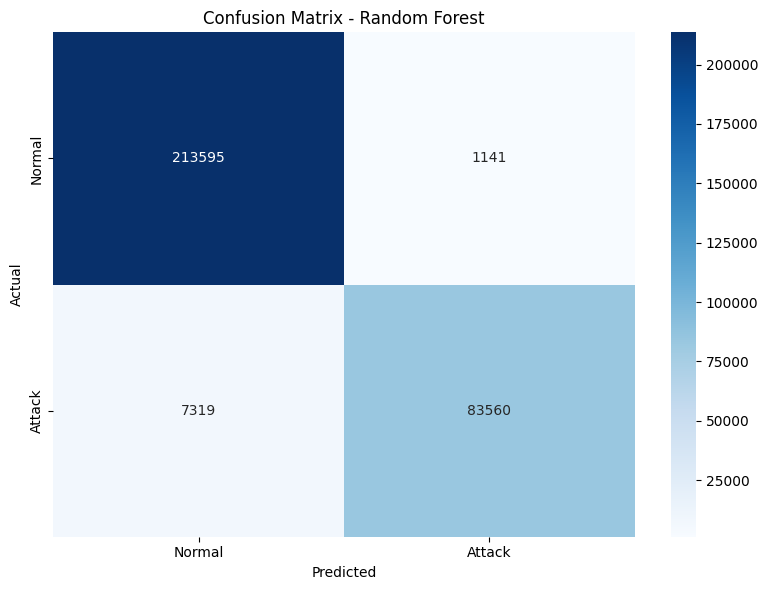


Feature Importance:
             feature  importance
6   modbus_req_count    0.338002
2      pkt_size_mean    0.170717
3            iat_min    0.146719
7  modbus_resp_count    0.115367
5           iat_mean    0.110129
1       pkt_size_max    0.090691
4            iat_max    0.028299
0       pkt_size_min    0.000075

Saved model to random_forest_model.pkl
Saved feature list to feature_list.txt

Dataset Info:
Normal flows: 715786
Attack flows: 302928
Total flows: 1018714


In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

def train_rf_model(df_normal, df_attack):
    """Train Random Forest classifier using DataFrames"""

    # Make copies so the original DataFrames are not modified
    df_normal = df_normal.copy()
    df_attack = df_attack.copy()

    # Add labels
    df_normal["label"] = 0  # Normal traffic
    df_attack["label"] = 1   # Attack traffic

    # Combine datasets
    df = pd.concat([df_normal, df_attack], ignore_index=True)

    # Select the 8 features
    feature_columns = [
        "pkt_size_min", "pkt_size_max", "pkt_size_mean",
        "iat_min", "iat_max", "iat_mean", "modbus_req_count", "modbus_resp_count"
    ]

    X = df[feature_columns]
    y = df["label"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=5,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)

    # Predictions
    y_pred = rf.predict(X_test)

    # Evaluate model
    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)

    print(f"Training Accuracy: {train_score:.4f}")
    print(f"Test Accuracy: {test_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred)

    # Print feature importance
    feature_importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": rf.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print("\nFeature Importance:")
    print(feature_importance_df)

    # Save feature importance to txt
    with open("feature_list.txt", "w") as f:
        for feat in feature_importance_df["feature"]:
            f.write(feat + "\n")

    # Save model
    joblib.dump(rf, "random_forest_model.pkl")
    print("\nSaved model to random_forest_model.pkl")
    print("Saved feature list to feature_list.txt")

    return rf, X_train, X_test, y_train, y_test, y_pred, feature_importance_df

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.title('Confusion Matrix - Random Forest')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    rf, X_train, X_test, y_train, y_test, y_pred, feature_importance_df = train_rf_model(df_normal, df_attack)

    print(f"\nDataset Info:")
    print(f"Normal flows: {len(df_normal)}")
    print(f"Attack flows: {len(df_attack)}")
    print(f"Total flows: {len(df_normal) + len(df_attack)}")

In [9]:
! pip install shap

Training Accuracy: 0.9727
Test Accuracy: 0.9723

Classification Report:
              precision    recall  f1-score   support

           0     0.9669    0.9947    0.9806    214736
           1     0.9865    0.9195    0.9518     90879

    accuracy                         0.9723    305615
   macro avg     0.9767    0.9571    0.9662    305615
weighted avg     0.9727    0.9723    0.9720    305615



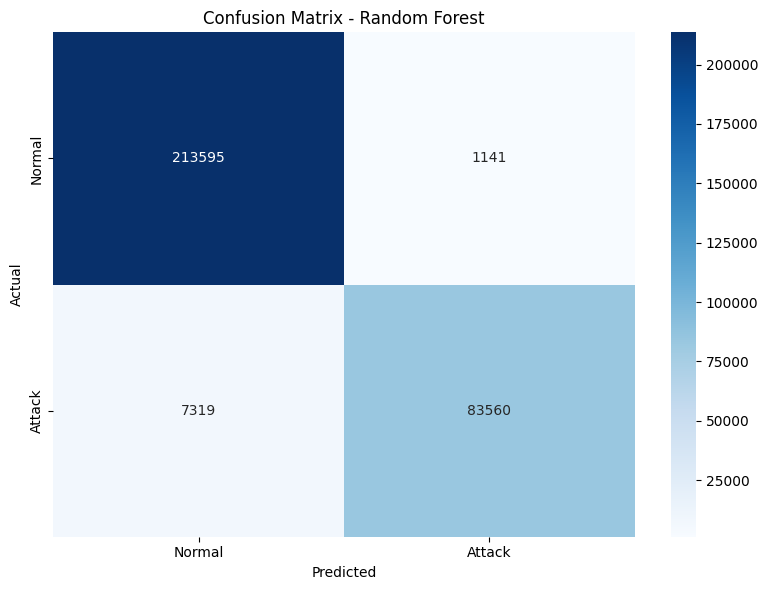


Feature Importance:
             feature  importance
6   modbus_req_count    0.338002
2      pkt_size_mean    0.170717
3            iat_min    0.146719
7  modbus_resp_count    0.115367
5           iat_mean    0.110129
1       pkt_size_max    0.090691
4            iat_max    0.028299
0       pkt_size_min    0.000075

SHAP Importance:
             feature  mean_abs_shap
6   modbus_req_count       0.183279
1       pkt_size_max       0.090885
2      pkt_size_mean       0.077014
3            iat_min       0.070827
7  modbus_resp_count       0.068231
5           iat_mean       0.056741
4            iat_max       0.028658
0       pkt_size_min       0.001504


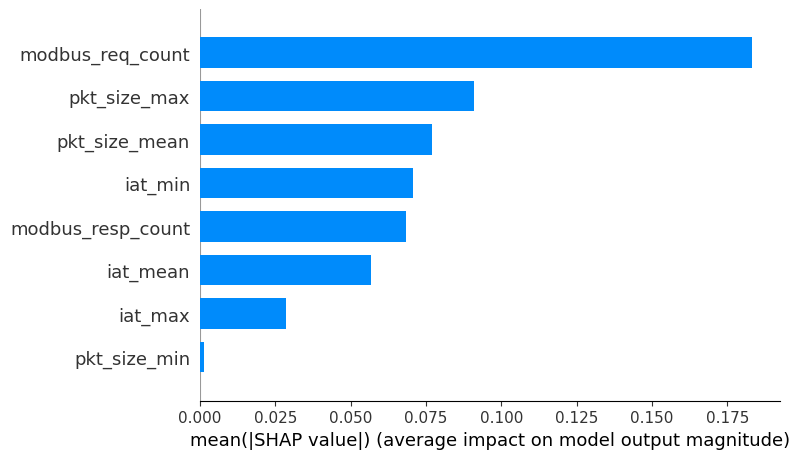

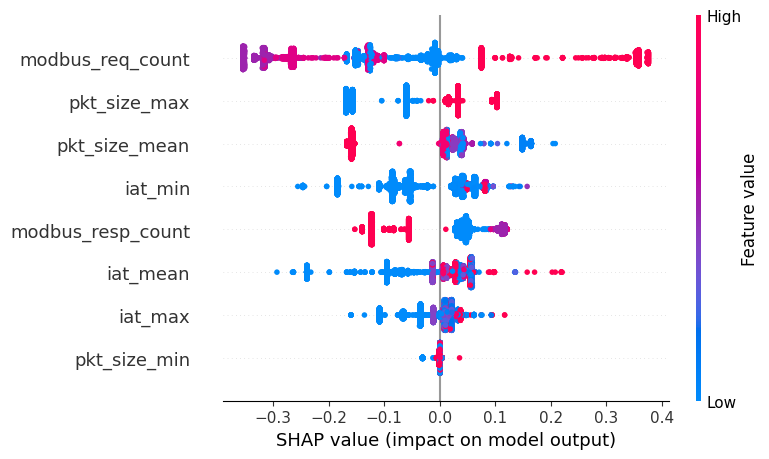


Saved model to random_forest_model.pkl
Saved feature list to feature_list.txt
Saved SHAP feature list to shap_feature_list.txt

Dataset Info:
Normal flows: 715786
Attack flows: 302928
Total flows: 1018714


In [11]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

def train_rf_model(df_normal, df_attack):
    """Train Random Forest classifier using DataFrames"""

    df_normal = df_normal.copy()
    df_attack = df_attack.copy()

    # Add labels
    df_normal["label"] = 0  # Normal traffic
    df_attack["label"] = 1  # Attack traffic

    # Combine datasets
    df = pd.concat([df_normal, df_attack], ignore_index=True)

    # Select the 8 features
    feature_columns = [
        "pkt_size_min", "pkt_size_max", "pkt_size_mean",
        "iat_min", "iat_max", "iat_mean", "modbus_req_count", "modbus_resp_count"
    ]

    X = df[feature_columns]
    y = df["label"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=5,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)

    # Predictions
    y_pred = rf.predict(X_test)

    # Evaluate model
    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)

    print(f"Training Accuracy: {train_score:.4f}")
    print(f"Test Accuracy: {test_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred)

    # Print feature importance
    feature_importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": rf.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print("\nFeature Importance:")
    print(feature_importance_df)

    # Save feature importance to txt
    with open("feature_list.txt", "w") as f:
        for feat in feature_importance_df["feature"]:
            f.write(feat + "\n")

    # SHAP analysis
    shap_importance_df = compute_shap_values(rf, X_train, X_test)

    # Save model
    joblib.dump(rf, "random_forest_model.pkl")
    print("\nSaved model to random_forest_model.pkl")
    print("Saved feature list to feature_list.txt")
    print("Saved SHAP feature list to shap_feature_list.txt")

    return rf, X_train, X_test, y_train, y_test, y_pred, feature_importance_df, shap_importance_df

def compute_shap_values(rf, X_train, X_test, sample_size=5000):
    """Compute and plot SHAP values for Random Forest"""

    # Sample for speed
    X_test_sample = X_test.sample(n=min(sample_size, len(X_test)), random_state=42)

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test_sample)

    # Handle different SHAP return types/shapes
    if isinstance(shap_values, list):
        # Usually binary classification: take class 1 (attack)
        shap_vals = shap_values[1]
    elif hasattr(shap_values, "values"):
        # New SHAP API may return Explanation object
        shap_vals = shap_values.values
    else:
        shap_vals = np.array(shap_values)

    # Reduce to 2D if needed
    # Common cases:
    # (n_samples, n_features, n_classes) -> take class 1
    # (n_samples, n_classes, n_features) -> take class 1
    if shap_vals.ndim == 3:
        if shap_vals.shape[2] == 2:
            shap_vals = shap_vals[:, :, 1]
        elif shap_vals.shape[1] == 2:
            shap_vals = shap_vals[:, 1, :]
        else:
            raise ValueError(f"Unexpected SHAP shape: {shap_vals.shape}")

    # Now shap_vals must be 2D: (n_samples, n_features)
    if shap_vals.ndim != 2:
        raise ValueError(f"SHAP values must be 2D after processing, got shape {shap_vals.shape}")

    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

    shap_importance_df = pd.DataFrame({
        "feature": X_test_sample.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values(by="mean_abs_shap", ascending=False)

    print("\nSHAP Importance:")
    print(shap_importance_df)

    with open("shap_feature_list.txt", "w") as f:
        for feat in shap_importance_df["feature"]:
            f.write(feat + "\n")

    # Bar plot
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_vals, X_test_sample, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()

    # Beeswarm plot
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_vals, X_test_sample, show=False)
    plt.tight_layout()
    plt.show()

    return shap_importance_df

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.title('Confusion Matrix - Random Forest')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    rf, X_train, X_test, y_train, y_test, y_pred, feature_importance_df, shap_importance_df = train_rf_model(df_normal, df_attack)

    print(f"\nDataset Info:")
    print(f"Normal flows: {len(df_normal)}")
    print(f"Attack flows: {len(df_attack)}")
    print(f"Total flows: {len(df_normal) + len(df_attack)}")

# Feature extraction at different window sizes

In [12]:
window_sizes = [4, 8, 16, 32]

normal_pcap = "/home/ubuntu/raw_data/normal/normal_traffic_2025-01-09_22_43_09.pcap"
attack_pcap = "/home/ubuntu/raw_data/attack/normal_traffic_2025-02-11_20_27_15.pcap"

for ws in window_sizes:
    print(f"\nProcessing window size = {ws}")

    # Process normal traffic
    df_normal = process_pcap_flows_modbus(normal_pcap, packets_per_window=ws)
    print(f"Processed {len(df_normal)} normal flows (ws={ws})")

    # Save normal
    normal_filename = f"normal_ws{ws}.csv"
    df_normal.to_csv(normal_filename, index=False)
    print(f"Saved {normal_filename}")

    # Process attack traffic
    df_attack = process_pcap_flows_modbus(attack_pcap, packets_per_window=ws)
    print(f"Processed {len(df_attack)} attack flows (ws={ws})")

    # Save attack
    attack_filename = f"attack_ws{ws}.csv"
    df_attack.to_csv(attack_filename, index=False)
    print(f"Saved {attack_filename}")


Processing window size = 4
Processed 715786 normal flows (ws=4)
Saved normal_ws4.csv
Processed 302928 attack flows (ws=4)
Saved attack_ws4.csv

Processing window size = 8
Processed 357899 normal flows (ws=8)
Saved normal_ws8.csv
Processed 151727 attack flows (ws=8)
Saved attack_ws8.csv

Processing window size = 16
Processed 178954 normal flows (ws=16)
Saved normal_ws16.csv
Processed 76118 attack flows (ws=16)
Saved attack_ws16.csv

Processing window size = 32
Processed 89484 normal flows (ws=32)
Saved normal_ws32.csv
Processed 38316 attack flows (ws=32)
Saved attack_ws32.csv


# Model Training


=== Window Size 4 ===
Training Accuracy: 0.9727
Test Accuracy: 0.9723

Classification Report:
              precision    recall  f1-score   support

           0     0.9669    0.9947    0.9806    214736
           1     0.9865    0.9195    0.9518     90879

    accuracy                         0.9723    305615
   macro avg     0.9767    0.9571    0.9662    305615
weighted avg     0.9727    0.9723    0.9720    305615



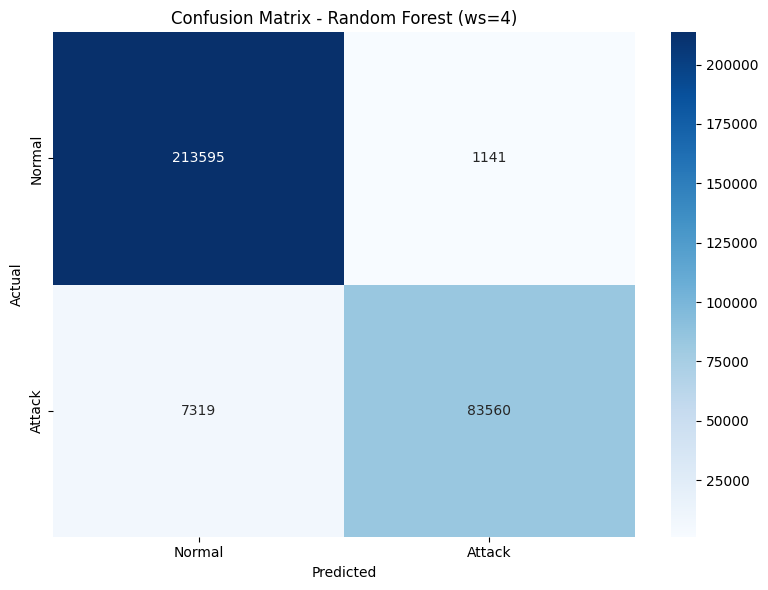


Feature Importance:
             feature  importance
6   modbus_req_count    0.338002
2      pkt_size_mean    0.170717
3            iat_min    0.146719
7  modbus_resp_count    0.115367
5           iat_mean    0.110129
1       pkt_size_max    0.090691
4            iat_max    0.028299
0       pkt_size_min    0.000075

Saved model to random_forest_model_ws4.pkl
Saved feature list to feature_list_ws4.txt

=== Window Size 8 ===
Training Accuracy: 0.9801
Test Accuracy: 0.9796

Classification Report:
              precision    recall  f1-score   support

           0     0.9727    0.9990    0.9857    107370
           1     0.9976    0.9338    0.9646     45518

    accuracy                         0.9796    152888
   macro avg     0.9851    0.9664    0.9752    152888
weighted avg     0.9801    0.9796    0.9794    152888



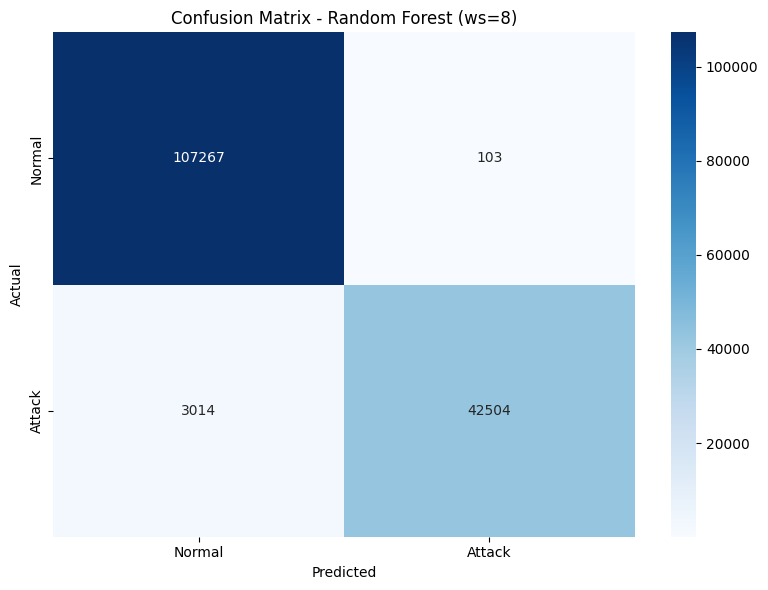


Feature Importance:
             feature  importance
6   modbus_req_count    0.348098
2      pkt_size_mean    0.258942
7  modbus_resp_count    0.211284
1       pkt_size_max    0.064244
4            iat_max    0.049682
5           iat_mean    0.025979
0       pkt_size_min    0.023892
3            iat_min    0.017879

Saved model to random_forest_model_ws8.pkl
Saved feature list to feature_list_ws8.txt

=== Window Size 16 ===
Training Accuracy: 0.9864
Test Accuracy: 0.9864

Classification Report:
              precision    recall  f1-score   support

           0     0.9823    0.9986    0.9904     53686
           1     0.9967    0.9577    0.9768     22836

    accuracy                         0.9864     76522
   macro avg     0.9895    0.9781    0.9836     76522
weighted avg     0.9866    0.9864    0.9863     76522



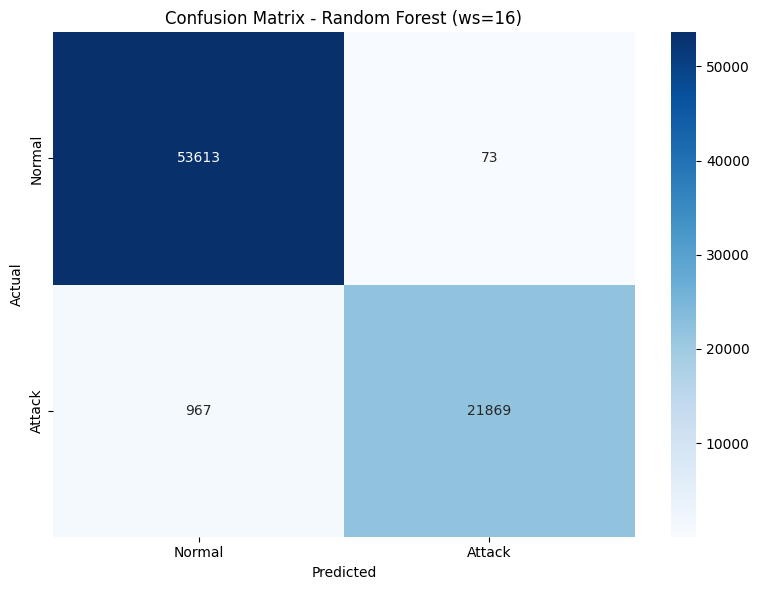


Feature Importance:
             feature  importance
4            iat_max    0.372645
6   modbus_req_count    0.178435
2      pkt_size_mean    0.175237
7  modbus_resp_count    0.147053
5           iat_mean    0.044028
1       pkt_size_max    0.031406
0       pkt_size_min    0.029382
3            iat_min    0.021813

Saved model to random_forest_model_ws16.pkl
Saved feature list to feature_list_ws16.txt

=== Window Size 32 ===
Training Accuracy: 0.9871
Test Accuracy: 0.9857

Classification Report:
              precision    recall  f1-score   support

           0     0.9809    0.9991    0.9899     26845
           1     0.9978    0.9545    0.9757     11495

    accuracy                         0.9857     38340
   macro avg     0.9893    0.9768    0.9828     38340
weighted avg     0.9860    0.9857    0.9856     38340



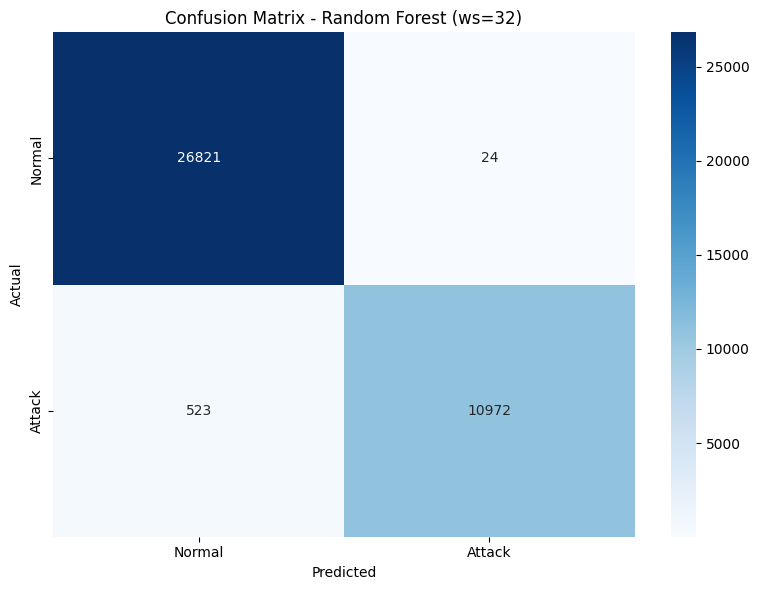


Feature Importance:
             feature  importance
6   modbus_req_count    0.280555
2      pkt_size_mean    0.185663
4            iat_max    0.157703
7  modbus_resp_count    0.128972
5           iat_mean    0.125455
3            iat_min    0.068631
0       pkt_size_min    0.028644
1       pkt_size_max    0.024378

Saved model to random_forest_model_ws32.pkl
Saved feature list to feature_list_ws32.txt

Summary:
   window_size  train_accuracy  test_accuracy                    model_file  \
0            4        0.972663       0.972318   random_forest_model_ws4.pkl   
1            8        0.980055       0.979613   random_forest_model_ws8.pkl   
2           16        0.986368       0.986409  random_forest_model_ws16.pkl   
3           32        0.987056       0.985733  random_forest_model_ws32.pkl   

       feature_list_file  
0   feature_list_ws4.txt  
1   feature_list_ws8.txt  
2  feature_list_ws16.txt  
3  feature_list_ws32.txt  

Saved summary to rf_results_summary.csv


In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

def plot_confusion_matrix(y_true, y_pred, ws):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.title(f'Confusion Matrix - Random Forest (ws={ws})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

def train_rf_model_from_csv(normal_csv, attack_csv, ws):
    """Train Random Forest using CSV files"""

    # Load CSV files
    df_normal = pd.read_csv(normal_csv)
    df_attack = pd.read_csv(attack_csv)

    # Add labels
    df_normal = df_normal.copy()
    df_attack = df_attack.copy()
    df_normal["label"] = 0
    df_attack["label"] = 1

    # Combine datasets
    df = pd.concat([df_normal, df_attack], ignore_index=True)

    # Select features
    feature_columns = [
        "pkt_size_min", "pkt_size_max", "pkt_size_mean",
        "iat_min", "iat_max", "iat_mean", "modbus_req_count", "modbus_resp_count"
    ]

    X = df[feature_columns]
    y = df["label"]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=5,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    rf.fit(X_train, y_train)

    # Predictions
    y_pred = rf.predict(X_test)

    # Metrics
    train_score = rf.score(X_train, y_train)
    test_score = rf.score(X_test, y_test)
    test_acc = accuracy_score(y_test, y_pred)

    print(f"\n=== Window Size {ws} ===")
    print(f"Training Accuracy: {train_score:.4f}")
    print(f"Test Accuracy: {test_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion matrix
    plot_confusion_matrix(y_test, y_pred, ws)

    # Feature importance
    feature_importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": rf.feature_importances_
    }).sort_values(by="importance", ascending=False)

    print("\nFeature Importance:")
    print(feature_importance_df)

    # Save feature list
    feature_list_file = f"feature_list_ws{ws}.txt"
    with open(feature_list_file, "w") as f:
        for feat in feature_importance_df["feature"]:
            f.write(feat + "\n")

    # Save model
    model_file = f"random_forest_model_ws{ws}.pkl"
    joblib.dump(rf, model_file)

    print(f"\nSaved model to {model_file}")
    print(f"Saved feature list to {feature_list_file}")

    return {
        "ws": ws,
        "train_acc": train_score,
        "test_acc": test_score,
        "feature_importance_df": feature_importance_df,
        "model_file": model_file,
        "feature_list_file": feature_list_file
    }

if __name__ == "__main__":
    window_sizes = [4, 8, 16, 32]
    results = []

    for ws in window_sizes:
        normal_csv = f"normal_ws{ws}.csv"
        attack_csv = f"attack_ws{ws}.csv"

        result = train_rf_model_from_csv(normal_csv, attack_csv, ws)
        results.append({
            "window_size": result["ws"],
            "train_accuracy": result["train_acc"],
            "test_accuracy": result["test_acc"],
            "model_file": result["model_file"],
            "feature_list_file": result["feature_list_file"]
        })

    results_df = pd.DataFrame(results)
    print("\nSummary:")
    print(results_df)

    results_df.to_csv("rf_results_summary.csv", index=False)
    print("\nSaved summary to rf_results_summary.csv")